# Comparativo de Heatmaps: Seaborn vs. Customizado (Bayesiano)
Este notebook demonstra por que um pacote padrão como o `seaborn` não atende aos requisitos visuais da nossa estatística bayesiana, justificando a criação da função `heatmap` no pacote `util_est_bayesiana.py`.

In [24]:
# @title 1. Instalação de dependências e Geração de Dados Fictícios
import pandas as pd
import numpy as np

# Para um heatmap 3x3 (A, B, C), precisamos gerar os pares:
protocolos = ["GPT-4", "Claude-3", "Llama-3"]

# Vamos criar uma matriz de probabilidades (fictícia)
dados = []
for i, p1 in enumerate(protocolos):
    for j, p2 in enumerate(protocolos):
        if i == j:
            dados.append({ "linha": p1, "coluna": p2, "p_esquerda": 0.0, "p_rope": 0.0, "p_direita": 0.0, "classificacao": "incerto", "probabilidade": 0.0 })
        elif i < j:
            # p1 vs p2
            # Ex: GPT-4 vs Claude-3 -> Equivalente
            if p1 == "GPT-4" and p2 == "Claude-3":
                p_esq, p_rope, p_dir, classif = 0.02, 0.96, 0.02, "equivalente"
            # Ex: GPT-4 vs Llama-3 -> Superior
            elif p1 == "GPT-4" and p2 == "Llama-3":
                p_esq, p_rope, p_dir, classif = 0.98, 0.01, 0.01, "superior"
            # Ex: Claude-3 vs Llama-3 -> Incerto
            elif p1 == "Claude-3" and p2 == "Llama-3":
                p_esq, p_rope, p_dir, classif = 0.60, 0.20, 0.20, "incerto"
            
            dados.append({ "linha": p1, "coluna": p2, "p_esquerda": p_esq, "p_rope": p_rope, "p_direita": p_dir, "classificacao": classif, "probabilidade": max(p_esq, p_rope, p_dir) })
            
            # O inverso (p2 vs p1)
            classif_inv = "inferior" if classif == "superior" else ("superior" if classif == "inferior" else classif)
            dados.append({ "linha": p2, "coluna": p1, "p_esquerda": p_dir, "p_rope": p_rope, "p_direita": p_esq, "classificacao": classif_inv, "probabilidade": max(p_esq, p_rope, p_dir) })

df_simulado = pd.DataFrame(dados)
df_simulado.attrs["nomes"] = protocolos
df_simulado.attrs["limiar"] = 0.95
df_simulado.attrs["rope"] = 0.15
df_simulado.attrs["n"] = 300


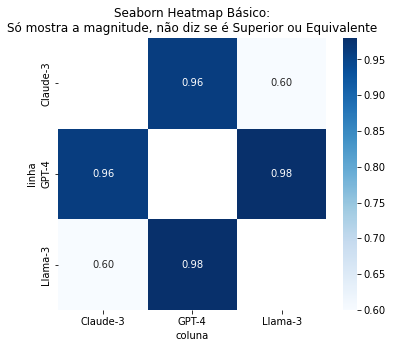

In [25]:
# @title 2. Opção 1: Usando o pacote padrão Seaborn (Básico)
import seaborn as sns
import matplotlib.pyplot as plt

# O Seaborn exige uma matriz pivotada (NxN) apenas com os valores contínuos.
def get_prob(row):
    if row["linha"] == row["coluna"]:
        return float("nan")
    return max(row["p_esquerda"], row["p_rope"], row["p_direita"])

df_simulado["prob_max"] = df_simulado.apply(get_prob, axis=1)
matriz_probs = df_simulado.pivot(index="linha", columns="coluna", values="prob_max")

plt.figure(figsize=(6, 5))
sns.heatmap(matriz_probs, annot=True, cmap="Blues", cbar=True, fmt=".2f")
plt.title("Seaborn Heatmap Básico:\nSó mostra a magnitude, não diz se é Superior ou Equivalente")
plt.show()


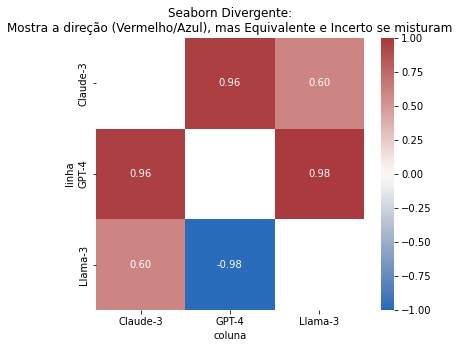

In [26]:
# @title 3. Opção 2: Seaborn "Hackeado" com Colormap Divergente
# Para tentar simular a DIREÇÃO com o Seaborn, precisamos "hackear" os dados.
# Fazemos probabilidades "superiores" serem positivas e "inferiores" negativas.
def get_prob_divergente(row):
    if row["linha"] == row["coluna"]:
        return float("nan")
    prob = row["probabilidade"]
    if row["classificacao"] == "inferior":
        return -prob
    return prob

df_simulado["prob_div"] = df_simulado.apply(get_prob_divergente, axis=1)
matriz_probs_div = df_simulado.pivot(index="linha", columns="coluna", values="prob_div")

plt.figure(figsize=(6, 5))
# Usamos vlag (Azul para positivo, Vermelho para negativo)
sns.heatmap(matriz_probs_div, annot=True, cmap="vlag", cbar=True, fmt=".2f", center=0, vmin=-1, vmax=1)
plt.title("Seaborn Divergente:\nMostra a direção (Vermelho/Azul), mas Equivalente e Incerto se misturam")
plt.show()


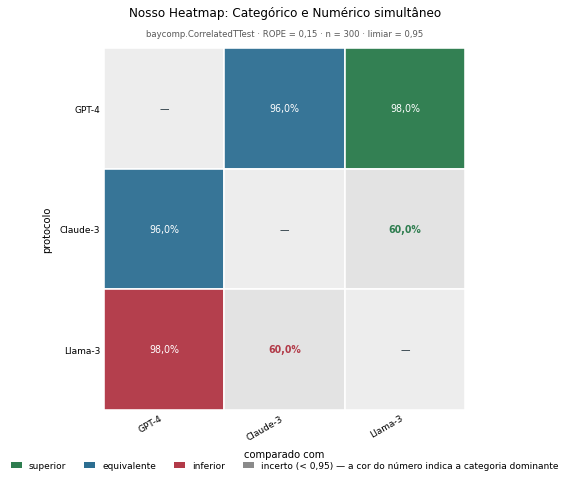

In [27]:
# @title 4. Opção 3: Usando nosso pacote (util_est_bayesiana.heatmap)
import sys
sys.path.append("../src")
from util_est_bayesiana import heatmap
import matplotlib.pyplot as plt

# O nosso heatmap é um mapa categórico-numérico híbrido:
# - A COR da célula mostra a DECISÃO FINAL (Verde=Superior, Azul=Equivalente, Vermelho=Inferior, Cinza=Incerto).
# - O NÚMERO mostra a PROBABILIDADE POSTERIOR real (sem precisar deixar o número negativo).
# - A INTENSIDADE da cor (alpha) reflete a força dessa probabilidade.

fig, caminho = heatmap(df_simulado, titulo="Nosso Heatmap: Categórico e Numérico simultâneo")
plt.show()
